In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
df = pd.read_csv(r"C:\Users\Dell\OneDrive - Sahana System Limited\Desktop\india-economy-etl\data\india_economy_clean.csv")
print("Data loaded successfully!")
print("Shape:", df.shape)
df.head()

Data loaded successfully!
Shape: (55, 4)


,year,fdi_inflow,gdp_growth_rate,inflation_rate
0,1970,0.072826,5.157230,5.092262
1,1971,0.070763,1.642930,3.079939
2,1972,0.024893,-0.553301,6.442097
3,1973,0.044330,3.295521,16.940816
4,1974,0.057241,1.185336,28.598734


In [5]:
print("=" * 50)
print("MODEL 1 — SIMPLE LINEAR REGRESSION")
print("=" * 50)
print("Question: Does inflation affect GDP growth in India?")
print()

X = df[['inflation_rate']].values
y = df['gdp_growth_rate'].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print()
print("What this means:")
print(f"For every 1% increase in inflation, GDP changes by {model.coef_[0]:.4f}%")
print(f"R2 of {r2:.4f} means inflation explains only {r2*100:.1f}% of GDP changes")


MODEL 1 — SIMPLE LINEAR REGRESSION
Question: Does inflation affect GDP growth in India?

Coefficient (slope): -0.0419
Intercept: 5.7756
R2 Score: 0.0039
RMSE: 3.1269

What this means:
For every 1% increase in inflation, GDP changes by -0.0419%
R2 of 0.0039 means inflation explains only 0.4% of GDP changes


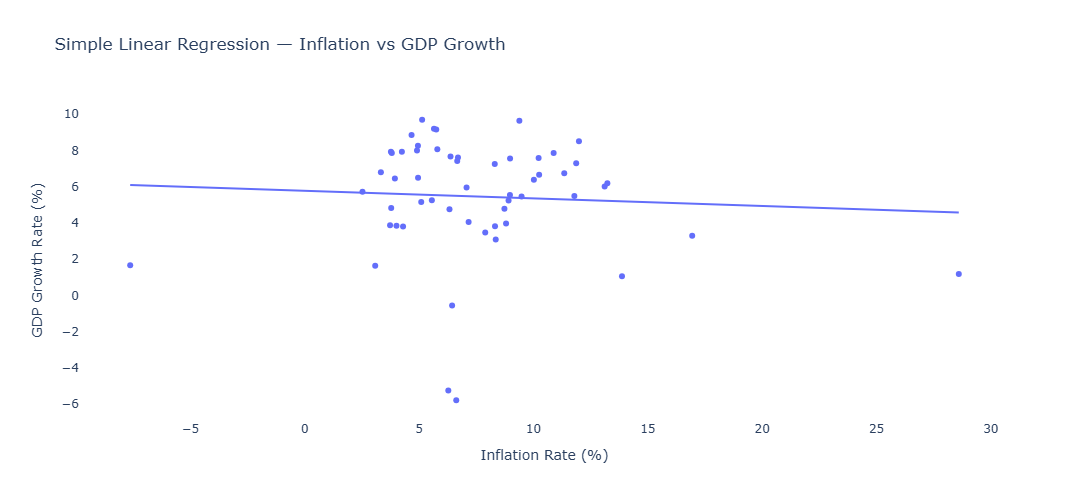

In [7]:
fig = px.scatter(
    df,
    x='inflation_rate',
    y='gdp_growth_rate',
    trendline='ols',
    title='Simple Linear Regression — Inflation vs GDP Growth',
    labels={
        'inflation_rate': 'Inflation Rate (%)',
        'gdp_growth_rate': 'GDP Growth Rate (%)'
    },
    hover_data=['year']
)

fig.update_layout(
    plot_bgcolor='white',
    width=800,
    height=500
)

fig.show()

MODEL 2 — MULTIPLE LINEAR REGRESSION
Question: Do inflation AND FDI together predict GDP better?

Inflation coefficient: -0.0313
FDI coefficient: 0.4272
Intercept: 5.3545
R2 Score: 0.0177
RMSE: 3.1053

What this means:
Inflation + FDI together explain 1.8% of GDP changes
Simple regression explained only 0.4% — multiple regression explains 1.8%



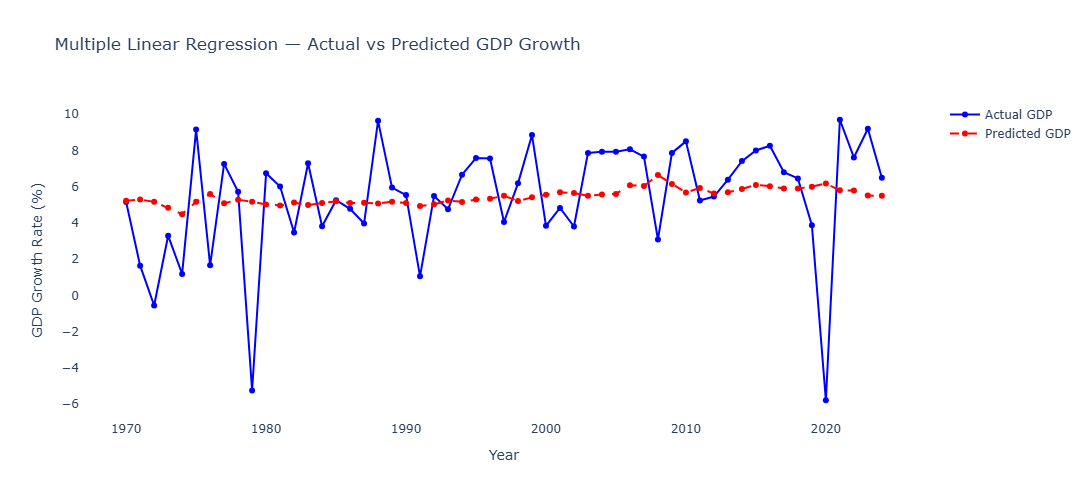

In [8]:
print("=" * 50)
print("MODEL 2 — MULTIPLE LINEAR REGRESSION")
print("=" * 50)
print("Question: Do inflation AND FDI together predict GDP better?")
print()

X = df[['inflation_rate', 'fdi_inflow']].values
y = df['gdp_growth_rate'].values

model_multi = LinearRegression()
model_multi.fit(X, y)

y_pred_multi = model_multi.predict(X)

r2_multi = r2_score(y, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y, y_pred_multi))

print(f"Inflation coefficient: {model_multi.coef_[0]:.4f}")
print(f"FDI coefficient: {model_multi.coef_[1]:.4f}")
print(f"Intercept: {model_multi.intercept_:.4f}")
print(f"R2 Score: {r2_multi:.4f}")
print(f"RMSE: {rmse_multi:.4f}")
print()
print("What this means:")
print(f"Inflation + FDI together explain {r2_multi*100:.1f}% of GDP changes")
print(f"Simple regression explained only 0.4% — multiple regression explains {r2_multi*100:.1f}%")
print()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['year'],
    y=y,
    mode='lines+markers',
    name='Actual GDP',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=df['year'],
    y=y_pred_multi,
    mode='lines+markers',
    name='Predicted GDP',
    line=dict(color='red', dash='dash')
))

fig.update_layout(
    title='Multiple Linear Regression — Actual vs Predicted GDP Growth',
    xaxis_title='Year',
    yaxis_title='GDP Growth Rate (%)',
    plot_bgcolor='white',
    hovermode='x unified',
    width=900,
    height=500
)

fig.show()

In [9]:
print("=" * 50)
print("MODEL 3 — OLS REGRESSION WITH STATISTICS")
print("=" * 50)

X_ols = sm.add_constant(df[['inflation_rate', 'fdi_inflow']])
y_ols = df['gdp_growth_rate']

ols_model = sm.OLS(y_ols, X_ols).fit()

print(ols_model.summary())

MODEL 3 — OLS REGRESSION WITH STATISTICS
                            OLS Regression Results                            
Dep. Variable:        gdp_growth_rate   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.4674
Date:                Wed, 10 Jun 2026   Prob (F-statistic):              0.629
Time:                        13:01:21   Log-Likelihood:                -140.36
No. Observations:                  55   AIC:                             286.7
Df Residuals:                      52   BIC:                             292.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
con

In [10]:
print("=" * 50)
print("MODEL 4 — GRANGER CAUSALITY TEST")
print("=" * 50)
print("Question: Does inflation CAUSE GDP changes in India?")
print()

granger_data = df[['gdp_growth_rate', 'inflation_rate']].dropna()
result = grangercausalitytests(granger_data, maxlag=3, verbose=True)

MODEL 4 — GRANGER CAUSALITY TEST
Question: Does inflation CAUSE GDP changes in India?


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.3320  , p=0.2538  , df_denom=51, df_num=1
ssr based chi2 test:   chi2=1.4104  , p=0.2350  , df=1
likelihood ratio test: chi2=1.3923  , p=0.2380  , df=1
parameter F test:         F=1.3320  , p=0.2538  , df_denom=51, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.0806  , p=0.3475  , df_denom=48, df_num=2
ssr based chi2 test:   chi2=2.3864  , p=0.3032  , df=2
likelihood ratio test: chi2=2.3343  , p=0.3113  , df=2
parameter F test:         F=1.0806  , p=0.3475  , df_denom=48, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.4934  , p=0.0721  , df_denom=45, df_num=3
ssr based chi2 test:   chi2=8.6439  , p=0.0344  , df=3
likelihood ratio test: chi2=7.9964  , p=0.0461  , df=3
parameter F test:         F=2.4934  , p=0.0721  , df_denom=45, df_num=3


In [11]:
print("=" * 50)
print("MODEL 5 — HYPOTHESIS TESTING")
print("=" * 50)
print()

gdp_pre2000 = df[df['year'] < 2000]['gdp_growth_rate']
gdp_post2000 = df[df['year'] >= 2000]['gdp_growth_rate']

t_stat, p_value = stats.ttest_ind(gdp_pre2000, gdp_post2000)

print(f"Average GDP before 2000: {gdp_pre2000.mean():.2f}%")
print(f"Average GDP after 2000: {gdp_post2000.mean():.2f}%")
print()
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: SIGNIFICANT difference between pre and post 2000 GDP")
    print("India's economy genuinely changed after 2000 — liberalisation worked")
else:
    print("Result: NO significant difference between pre and post 2000 GDP")
    print("Statistically India's growth rate did not change significantly after 2000")

MODEL 5 — HYPOTHESIS TESTING

Average GDP before 2000: 4.80%
Average GDP after 2000: 6.26%

T-statistic: -1.7386
P-value: 0.0879

Result: NO significant difference between pre and post 2000 GDP
Statistically India's growth rate did not change significantly after 2000
